In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#seleccionamos el dataframe diabetic_data_cleaned
df = pd.read_csv('../etl/diabetic_data_cleaned.csv')

In [14]:
# Verificamos las columnas del dataframe
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group',
       'diag_2_group', 'diag_3_group', 'med_change_count', 'treatment_status',
       'readmitted_status', 'age_numeric', 'hospital_stay_type',
       'admission_type_desc', 

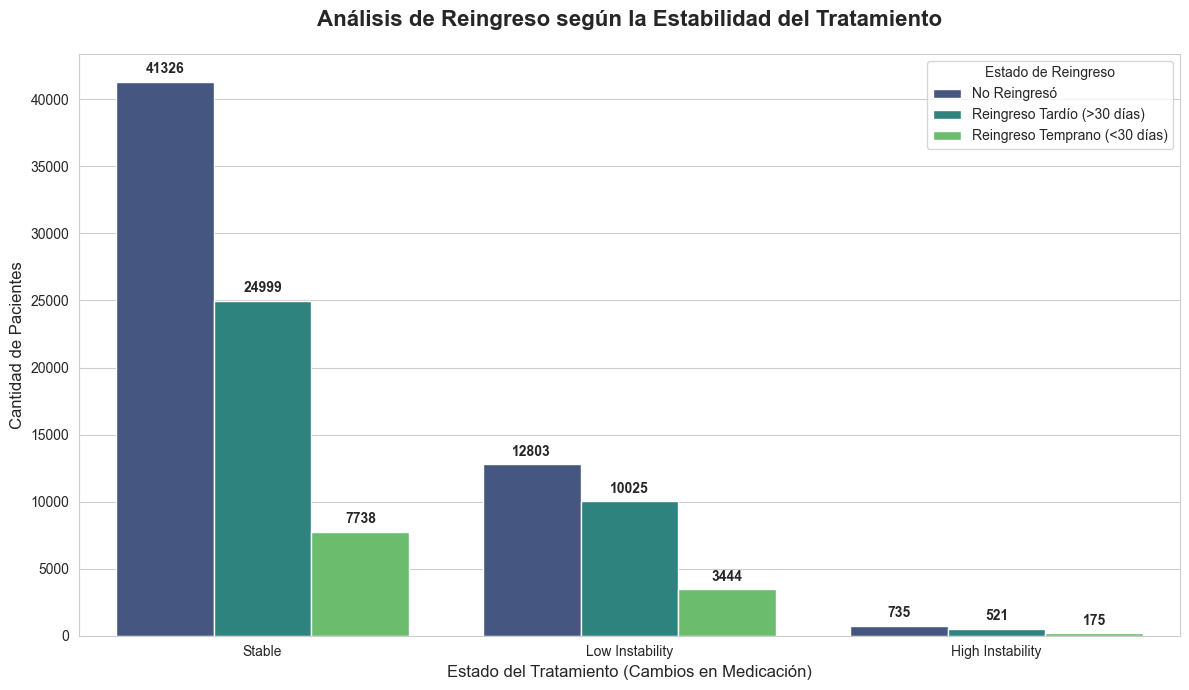

In [15]:
# 1. Configuración de estilo y tamaño
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. Creación del gráfico de barras
# Usamos 'treatment_status' vs 'readmitted_status'
ax = sns.countplot(
    data=df, 
    x='treatment_status', 
    hue='readmitted_status',
    palette='viridis', 
    order=['Stable', 'Low Instability', 'High Instability']
)

# 3. Personalización del gráfico
plt.title('Análisis de Reingreso según la Estabilidad del Tratamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Estado del Tratamiento (Cambios en Medicación)', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.legend(title='Estado de Reingreso', loc='upper right')

# 4. Etiquetas de valor sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()

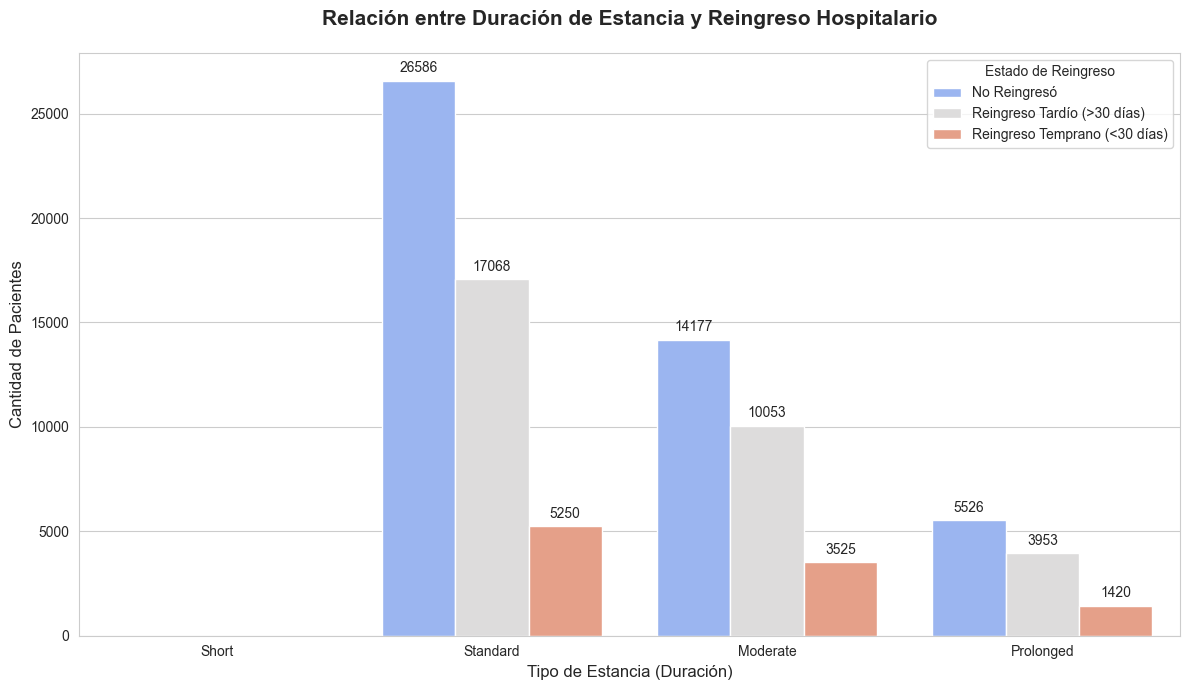

In [16]:
# 1. Configuración de estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. Creación del gráfico de barras para la estancia
# Usamos 'hospital_stay_type' en el eje X y 'readmitted_status' para el color
ax = sns.countplot(
    data=df, 
    x='hospital_stay_type', 
    hue='readmitted_status',
    palette='coolwarm',
    # Ordenamos de estancias cortas a largas para que el gráfico tenga sentido lógico
    order=['Short', 'Standard', 'Moderate', 'Prolonged']
)

# 3. Personalización
plt.title('Relación entre Duración de Estancia y Reingreso Hospitalario', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tipo de Estancia (Duración)', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.legend(title='Estado de Reingreso', loc='upper right')

# 4. Etiquetas de valor sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

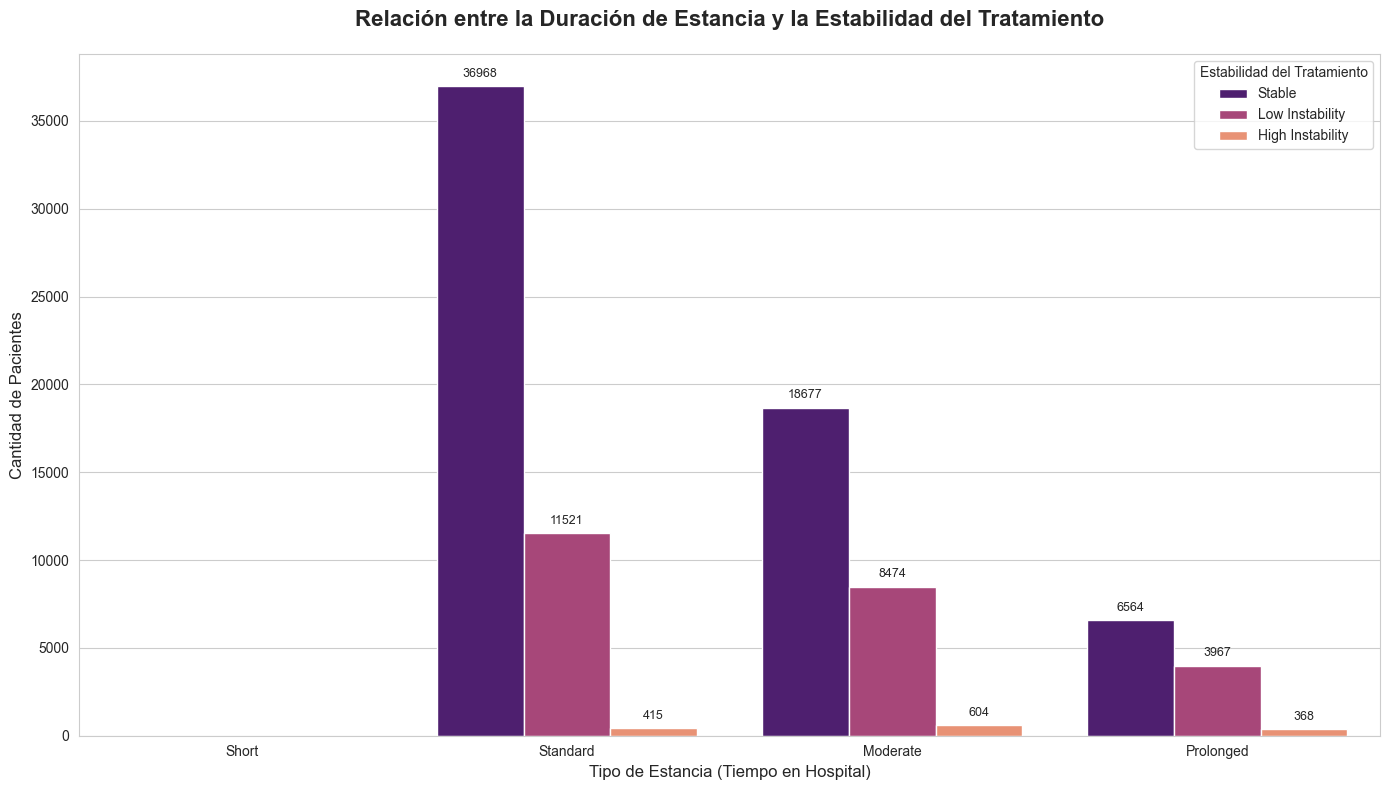

In [17]:
# 1. Configuración de estilo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 2. Creación del gráfico
# X: Duración de la estancia
# Hue: Estado del tratamiento (Estabilidad)
ax = sns.countplot(
    data=df,
    x='hospital_stay_type',
    hue='treatment_status',
    palette='magma',
    order=['Short', 'Standard', 'Moderate', 'Prolonged'],
    hue_order=['Stable', 'Low Instability', 'High Instability']
)

# 3. Personalización
plt.title('Relación entre la Duración de Estancia y la Estabilidad del Tratamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Estancia (Tiempo en Hospital)', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.legend(title='Estabilidad del Tratamiento', loc='upper right')

# 4. Etiquetas de valor (opcional, para ver los números exactos)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

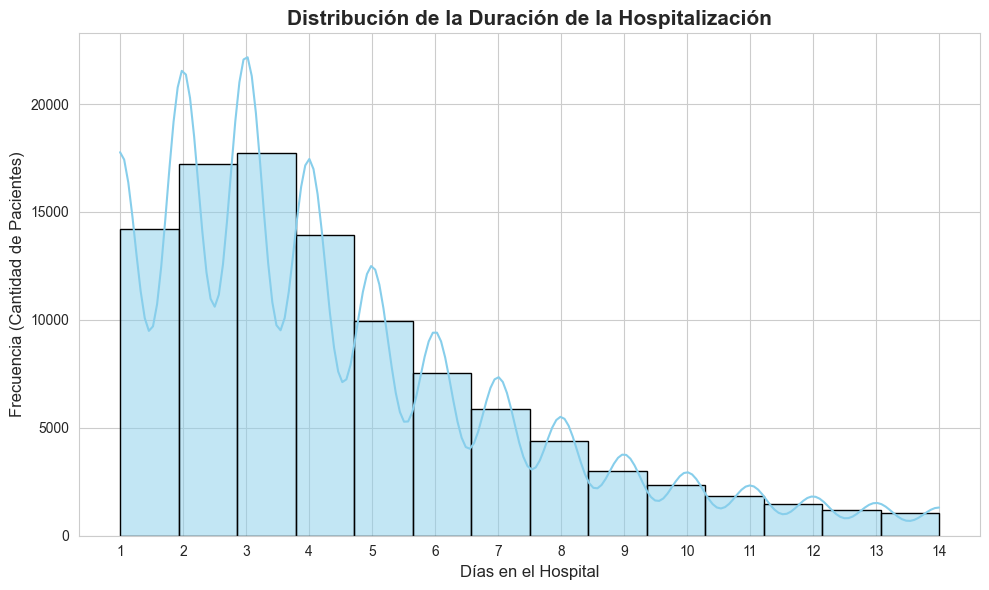

In [18]:
# 1. Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Creación del Histograma
# Usamos 'time_in_hospital' que es la variable numérica original
sns.histplot(
    data=df, 
    x='time_in_hospital', 
    kde=True,          # Agrega la línea de tendencia (densidad)
    bins=14,           # Un bin por cada día (ya que el máximo suele ser 14)
    color='skyblue', 
    edgecolor='black'
)

# 3. Personalización
plt.title('Distribución de la Duración de la Hospitalización', fontsize=15, fontweight='bold')
plt.xlabel('Días en el Hospital', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Pacientes)', fontsize=12)

# Ajustar los ticks del eje X para que muestren cada día del 1 al 14
plt.xticks(range(1, 15))

plt.tight_layout()
plt.show()

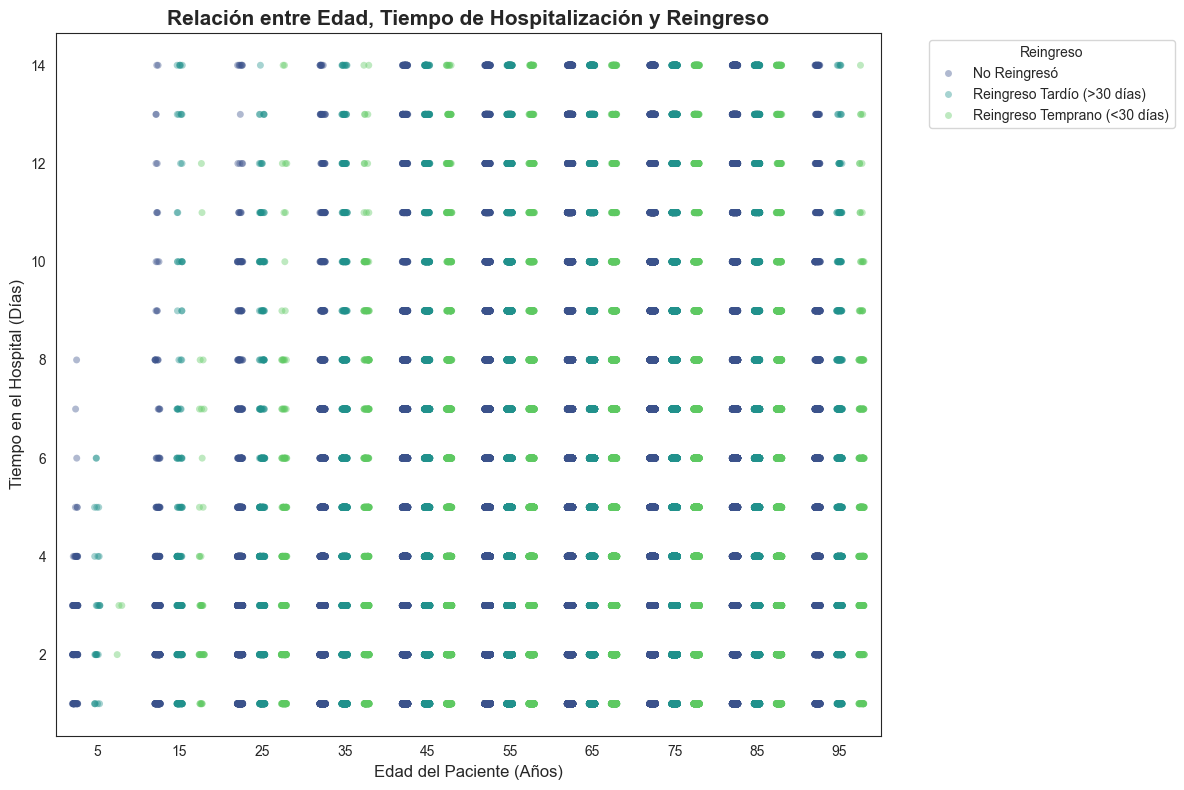

In [19]:
# 1. Configuración de estilo
plt.figure(figsize=(12, 8))
sns.set_style("white")

# 2. Creación del gráfico de dispersión
# Usamos 'jitter' para que los puntos no se encimen totalmente y podamos ver la densidad
ax = sns.stripplot(
    data=df, 
    x='age_numeric', 
    y='time_in_hospital', 
    hue='readmitted_status',
    palette='viridis',
    alpha=0.4,       # Transparencia para ver dónde hay más densidad de puntos
    dodge=True       # Separa un poco los colores para comparar mejor
)

# 3. Personalización
plt.title('Relación entre Edad, Tiempo de Hospitalización y Reingreso', fontsize=15, fontweight='bold')
plt.xlabel('Edad del Paciente (Años)', fontsize=12)
plt.ylabel('Tiempo en el Hospital (Días)', fontsize=12)
plt.legend(title='Reingreso', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()